In [1]:
from pyfiles.ftsteane import *
from HPC.Upload.classes import *
from random import choices
import math
import cmath
import itertools

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Bitstream Vera Sans",
    "font.sans-serif": "Helvetica",
})

In [2]:
def breakeven(p: int, n: int, x: list):       #p: Error probability, n: physical qubits per log. qubit, x: list with k Layers of n-qubit transversal gates
    log_err = []
    for k in x:
        term1 = (1-p)**(k*(n-1))
        term2 = (1+p*(n-1))**k
        log_err.append(1 - term1*term2)
    return log_err

In [3]:
p , p1, p2,  n = 0.01, 0.001, 0.0001, 9

x = [i for i in range(300)]
y, y1, y2 = breakeven(p, n, x), breakeven(p1, n, x), breakeven(p2, n, x)

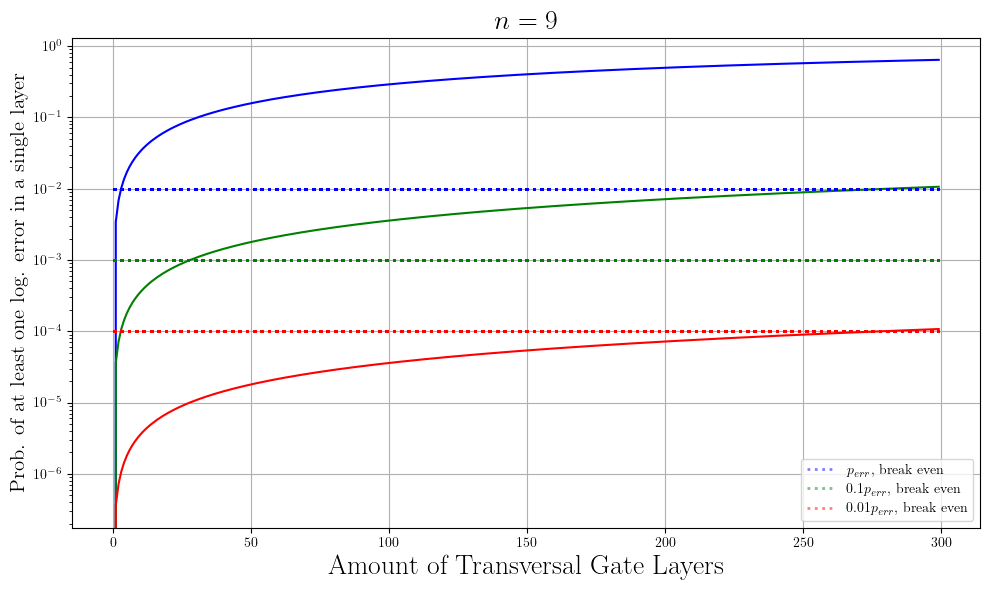

In [12]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(x,y,color="blue"), plt.plot(x,y1,color="green"), plt.plot(x,y2,color="red")
ax1.hlines([p for i in range(len(x))], min(x), max(x), color = "blue", linestyles=":", label=r"$p_{err}$, break even", linewidth=2, alpha=0.5)
ax1.hlines([p1 for i in range(len(x))], min(x), max(x), color = "green", linestyles=":", label=r"$0.1p_{err}$, break even", linewidth=2, alpha=0.5)
ax1.hlines([p2 for i in range(len(x))], min(x), max(x), color = "red", linestyles=":", label=r"$0.01p_{err}$, break even", linewidth=2, alpha=0.5)
ax1.set_xlabel("Amount of Transversal Gate Layers", fontsize=20)
ax1.set_ylabel("Prob. of at least one log. error in a single layer", fontsize=15)
ax1.set_yscale("log")
ax1.set_title(rf"$n = {n}$", fontsize=20)
plt.tight_layout()
plt.legend()
plt.grid()
plt.show()

In [50]:
x = np.linspace(0.001, 0.004, 5)
y, y_qec = [], []
layers = 10
shots = 10000
bias = 0
for i in x:
    #dustin_qec = RepCode_z(3,1)
    dustin_qec = RotSurf9q(1,0)
    dustin_qec.err = True
    dustin_qec.postselection = True
    for k in range(layers):
        dustin_qec.id(0)
        # if k == 5:
        #     dustin_qec.qec(0)
        # if k == 10:
        #     dustin_qec.qec(0)
        if k != 0 and (k+1)%6 == 0:
             dustin_qec.qec(0)
            #  dustin_qec.qec(0)
    # dustin_qec.qec(0)
    dustin_qec.readout(0, shots, i)


    # phys = QuantumCircuit(1)
    # for k in range(layers):
    #     phys.h(0)
    #     phys.z(0)
    # phys.measure_all()
    # p_error = pauli_error([["X",i/2],["I",1-i],["Z",i/2]])
    # noise_model = NoiseModel()
    # noise_model.add_all_qubit_quantum_error(p_error, ["h","id","s","sdg","t","tdg","x","z"])  # Apply to single-qubit gates
    # sim = AerSimulator()
    # job = sim.run(phys, shots=shots, noise_model=noise_model)
    # result = job.result()
    # counts = result.get_counts()
    # bitstring = list(counts.keys())
    # bitstring = [i.replace(" ","") for i in bitstring]
    # hmm = list(counts.values())
    # correct = 0
    # for i in range(len(bitstring)):
    #     if bitstring[i] == "0":
    #         correct += hmm[i]
    # y.append(1-correct/shots)
    y_qec.append(1-dustin_qec.zeros/(dustin_qec.zeros+dustin_qec.ones))

In [51]:
print("Zeros: ", dustin_qec.zeros)
print("Ones: ", dustin_qec.ones)
print("Preselection: ", dustin_qec.preselected)
print("Postselection: ", dustin_qec.post)

Zeros:  0.9016
Ones:  0.0045
Preselection:  0
Postselection:  0.0939


[0.00010256410256404003, 0.0010432968179446833, 0.0018018018018017834, 0.0029038502903850905, 0.004966339256152641]


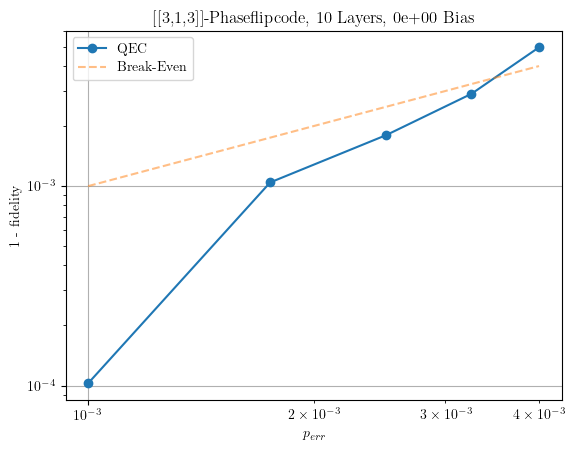

In [52]:
# print(y)
print(y_qec)

y_even = x.copy()
# plt.plot(x,y,marker="x",label="No QEC")
plt.plot(x,y_qec,marker="o",label="QEC")
plt.plot(x,y_even,linestyle="--",label="Break-Even",alpha=0.5)
plt.grid()
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.ylabel(r"1 - fidelity")
plt.xlabel(r"$p_{err}$")
plt.title("[[3,1,3]]-Phaseflipcode, {} Layers, {:.0e} Bias".format(layers, bias))
plt.show()

In [127]:
dustin = RotSurf9q(1,0)

gates(dustin.qc)

dustin.qec(0)

gates(dustin.qc)

Amount of gates in this circuit:  12
Amount of gates in this circuit:  44
